<a href="https://colab.research.google.com/github/nlan082/bai_tap_AI/blob/main/VD2_1_Mua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 6.1 MB/s eta 0:00:00


In [6]:
#khai bao thu vien
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
#inputs, output
wind=ctrl.Antecedent(np.arange(0.7, 3.2, 0.1), 'wind')
temperature=ctrl.Antecedent(np.arange(20.4, 39.6, 0.1), 'temperature')
rainfall=ctrl.Consequent(np.arange(0.2, 9.2, 0.1), 'rainfall')
#thiet lap ham lien thuoc
wind['very-low']=fuzz.trimf(wind.universe, [0.7, 1.1, 1.5])
wind['low']=fuzz.trimf(wind.universe, [1.1, 1.5, 1.9])
wind['normal']=fuzz.trimf(wind.universe, [1.5, 1.9, 2.3])
wind['high']=fuzz.trimf(wind.universe, [1.9, 2.3, 2.7])
wind['very-high']=fuzz.trimf(wind.universe, [2.3, 2.7, 3.1])
temperature['very-low']=fuzz.trimf(temperature.universe, [20.4, 23.6, 26.8])
temperature['low']=fuzz.trimf(temperature.universe, [23.6, 26.8, 30])
temperature['normal']=fuzz.trimf(temperature.universe, [26.8, 30, 33.2])
temperature['high']=fuzz.trimf(temperature.universe, [30, 33.2, 36.4])
temperature['very-high']=fuzz.trimf(temperature.universe, [33.2, 36.4, 39.6])
rainfall['very-low']=fuzz.trimf(rainfall.universe, [0.2, 1.7, 3.2])
rainfall['low']=fuzz.trimf(rainfall.universe, [1.7, 3.2, 4.7])
rainfall['normal']=fuzz.trimf(rainfall.universe, [3.2, 4.7, 6.2])
rainfall['high']=fuzz.trimf(rainfall.universe, [4.7, 6.2, 7.7])
rainfall['very-high']=fuzz.trimf(rainfall.universe, [6.2, 7.7, 9.2])





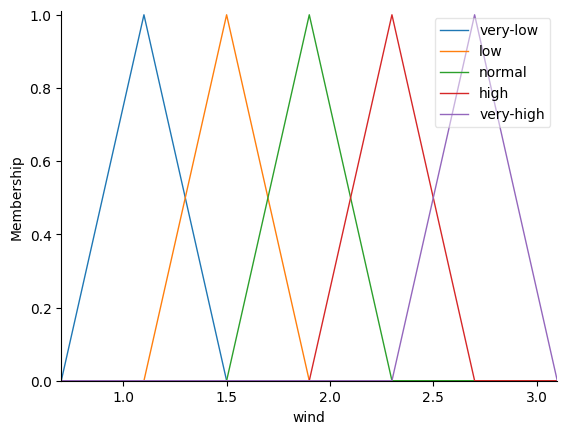

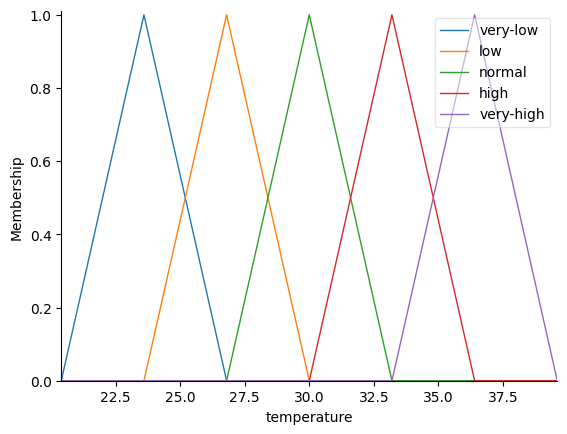

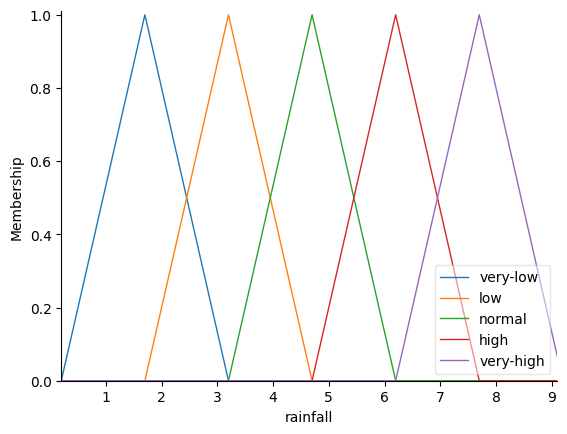

In [7]:
wind.view()
temperature.view()
rainfall.view()

In [8]:
#thiet lap luat
rule1= ctrl.Rule(wind['very-low']&temperature['very-low'], rainfall['very-low'])
rule2= ctrl.Rule(wind['low']&temperature['low'], rainfall['low'])
rule3= ctrl.Rule(wind['normal']&temperature['normal'], rainfall['normal'])
rule4= ctrl.Rule(wind['high']&temperature['high'], rainfall['high'])
rule5= ctrl.Rule(wind['very-high']&temperature['very-high'], rainfall['very-high'])
rule6= ctrl.Rule(wind['low']&temperature['very-high'], rainfall['high'])
rule7= ctrl.Rule(wind['normal']&temperature['low'], rainfall['normal'])
rule8= ctrl.Rule(wind['high']&temperature['high'], rainfall['high'])

4.700000000000224


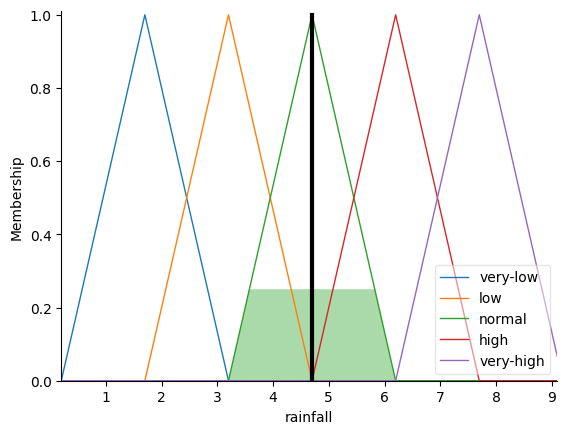

In [9]:
rainfalling_ctrl= ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
rainfalling= ctrl.ControlSystemSimulation(rainfalling_ctrl)
rainfalling.input['wind']= 2.2
rainfalling.input['temperature']= 30
rainfalling.compute()
print(rainfalling.output['rainfall'])
rainfall.view(sim=rainfalling)